In [33]:
import numpy as np
import time
import cv2
import matplotlib.pyplot as plt

### Binarization (1) - Direct Implementation (Nested Loops)

In this method, we perform a sequential pass over every pixel in the image using double `for` loops (iterating row by row, and column by column). 

For each pixel, we use an `if` condition to check whether its value is greater than the defined Threshold. If it is, its value is changed to 255 (white). Since we pre-allocated an array initialized entirely with zeros (black), there is no need to use an `else` condition.

In [34]:
def binarize_direct_loop(img: np.ndarray, threshold: int = 127):
    """
    Performs image binarization using direct nested loops.
    
    Inputs:
        - img: Must be a 2D numpy array (grayscale image).
        - threshold: Must be an integer between 0 and 255.

    Output:
        - return: A 2D numpy array (binarized image).
    """
    
   # Input Validation (Raising exceptions)
    if not isinstance(img, np.ndarray) or len(img.shape) != 2:
        raise TypeError("Input must be a 2D grayscale image (NumPy array).")
        
    if not isinstance(threshold, int) or not (0 <= threshold <= 255):
        raise ValueError("Threshold must be an integer between 0 and 255.")

    # Preparations (Allocating output array, initializing to 0 to avoid 'else' later)
    rows, cols = img.shape
    out = np.zeros((rows, cols), dtype=np.uint8)

    # Critical Loop with stopping criterion (Looping over rows and columns)
    for i in range(rows):
        for j in range(cols):
            if img[i, j] > threshold:
                out[i, j] = 255
                
    # 6. Conclusion
    return out

### Binarization (2) - Vectorized Implementation (NumPy)

In this method, we abandon manual loops and utilize the vectorized capabilities of the NumPy library. We apply the condition directly to the entire matrix at once (`img > threshold`), which creates a "boolean mask" (an array of True/False values). Using this mask, we instantly change the values of all pixels that passed the threshold to 255.

In [35]:
def binarize_vector(img: np.ndarray, threshold: int = 127):
    """
    Performs image binarization using NumPy vectorization (boolean indexing).
    
    Inputs:
        - img: Must be a 2D numpy array (grayscale image).
        - threshold: Must be an integer between 0 and 255.
    
    Output:
        - return: A 2D numpy array (binarized image).
    """
    
    # Input Validation (Raising exceptions)
    if not isinstance(img, np.ndarray) or len(img.shape) != 2:
        raise TypeError("Input must be a 2D grayscale image (NumPy array).")
        
    if not isinstance(threshold, int) or not (0 <= threshold <= 255):
        raise ValueError("Threshold must be an integer between 0 and 255.")

    # Preparations
    rows, cols = img.shape
    out = np.zeros((rows, cols), dtype=np.uint8)

    # Critical Loop / Vectorized Implementation
    # Using boolean indexing to update values in one vectorized operation
    out[img > threshold] = 255
                
    # Conclusion
    return out

### Binarization (3) - Look-Up Table (LUT) Implementation

In this method, we use a classic and highly efficient image processing technique called a Look-Up Table (LUT). Since every pixel in a grayscale image can only take on 256 possible values (from 0 to 255), there is no point in calculating the condition repeatedly for the millions of pixels in the image. 

Instead, we prepare a small array of 256 cells in advance (our table). The index of each cell represents the original pixel value, and the content of the cell contains the new value (0 or 255, depending on whether it passed the threshold). We then feed the entire image as indices into this table, and all image values are instantly replaced with their new equivalents in a vectorized manner.

In [36]:
def create_binarize_lut(threshold: int):
    """
    Creates a Look-Up Table (LUT) for binarization based on the given threshold.
    
    Input:
        - threshold: Must be an integer between 0 and 255.

    Output:
        - return: A 1D numpy array (Look-Up Table).
    """
    return np.array([255 if i > threshold else 0 for i in range(256)], dtype=np.uint8)

def binarize_lut(img: np.ndarray, lut: np.ndarray):
    """
    Performs image binarization using a Look-Up Table (LUT).
    
    Inputs:
        - img: Must be a 2D numpy array (grayscale image).
        - lut: Must be a 1D numpy array (Look-Up Table).
    
    Output:
        - return: A 2D numpy array (binarized image).   
    """
    
    # Input Validation
    if not isinstance(img, np.ndarray) or len(img.shape) != 2:
        raise TypeError("Input must be a 2D grayscale image (NumPy array).")
        
    if not isinstance(lut, np.ndarray) or len(lut.shape) != 1 or lut.size != 256:
        raise ValueError("LUT must be a 1D numpy array with 256 elements.")

    # Critical Loop / Implementation
    # NumPy uses the image matrix itself as indices to map to the LUT array instantly
    out = lut[img]

    # Conclusion
    return out

### Binarization - Visual Result

In this section, we load an original image, ensure it is in Grayscale format, and apply our Binarization function to verify its correctness. We display the original image next to the processed binary image.

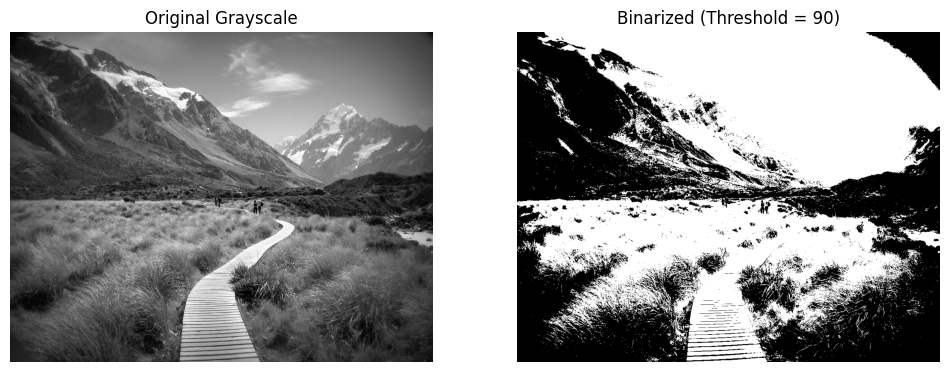

In [37]:
# 1. Load the image (replace with your actual image file name)
img_color = cv2.imread('image.jpg')

if img_color is None:
    print("Error: Could not load image. Please check the file path.")
else:
    # 2. Convert to Grayscale
    img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
    
    # 3. Apply the Binarization (Using LUT method as an example)
    threshold_val = 90
    lut = create_binarize_lut(threshold_val)
    binary_result = binarize_lut(img_gray, lut)
    
    # 4. Display the results side-by-side
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.title("Original Grayscale")
    plt.imshow(img_gray, cmap='gray')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.title(f"Binarized (Threshold = {threshold_val})")
    plt.imshow(binary_result, cmap='gray')
    plt.axis('off')
    
    plt.show()

### Binarization - Performance Benchmark

To meet the assignment requirements, we compare the execution speed of our three implementations against the built-in OpenCV library function (`cv2.threshold`). 

To get accurate and stable results, we use `time.perf_counter()` and average the execution time over multiple runs (10 iterations).

In [38]:
# Number of iterations for a reliable average
num_runs = 10
threshold_val = 110

# 1. Measure Direct Method
start_time = time.perf_counter()
for _ in range(num_runs):
    binarize_direct_loop(img_gray, threshold_val)
time_direct = ((time.perf_counter() - start_time) / num_runs) * 1000

# 2. Measure Vectorized Method
start_time = time.perf_counter()
for _ in range(num_runs):
    binarize_vector(img_gray, threshold_val)
time_vector = ((time.perf_counter() - start_time) / num_runs) * 1000

# 3. Measure LUT Method
lut = create_binarize_lut(threshold_val)  # Pre-create LUT for fair timing
start_time = time.perf_counter()
for _ in range(num_runs):
    binarize_lut(img_gray, lut)
time_lut = ((time.perf_counter() - start_time) / num_runs) * 1000

# 4. Measure OpenCV Library Function (For comparison)
start_time = time.perf_counter()
for _ in range(num_runs):
    # cv2.threshold returns a tuple (ret_val, thresholded_image)
    cv2.threshold(img_gray, threshold_val, 255, cv2.THRESH_BINARY)
time_cv2 = ((time.perf_counter() - start_time) / num_runs) * 1000

# Print the final Benchmark Table
print("--- Execution Time Comparison (Binarization) ---")
print(f"Direct (Loops):      {time_direct:.4f} ms")
print(f"Vectorized (NumPy):  {time_vector:.4f} ms")
print(f"LUT Method:          {time_lut:.4f} ms")
print(f"OpenCV Built-in:     {time_cv2:.4f} ms")

--- Execution Time Comparison (Binarization) ---
Direct (Loops):      223.3026 ms
Vectorized (NumPy):  2.1115 ms
LUT Method:          3.7523 ms
OpenCV Built-in:     0.0483 ms


### Gamma Correction (1) - Direct Implementation (Nested Loops)

In this method, we iterate through each pixel individually using nested loops. To apply the non-linear gamma formula accurately, we must handle data type conversions. Each pixel's integer value (`uint8`) is normalized to a float between 0.0 and 1.0. The gamma power function is applied to this normalized value, multiplied back by 255, and finally cast back to a `uint8` integer.

In [39]:
def gamma_direct(img: np.ndarray, gamma: float = 1.0):
    """
    Applies gamma correction to an image using direct nested loops.
    Formula: V_out = 255 * (V_in / 255) ^ gamma
    
    Inputs:
      - img: Must be a 2D numpy array (grayscale image).
      - gamma: Must be a positive number (float or int).
    
    output:
      - return: A 2D numpy array (gamma-corrected image).
    """
    
    # Input Validation
    if not isinstance(img, np.ndarray) or len(img.shape) != 2:
        raise TypeError("Input must be a 2D grayscale image (NumPy array).")
        
    if not isinstance(gamma, (int, float)) or gamma <= 0:
        raise ValueError("Gamma must be a positive number greater than 0.")

    # Preparations
    rows, cols = img.shape
    out = np.zeros((rows, cols), dtype=np.uint8)

    # Critical Loop / Implementation
    for i in range(rows):
        for j in range(cols):
            # Normalize to float, apply formula, and cast back to uint8
            norm_val = img[i, j] / 255.0
            out[i, j] = np.uint8(255.0 * (norm_val ** gamma))
                
    # Conclusion
    return out

### Gamma Correction (2) - Vectorized Implementation

This approach leverages NumPy's vectorized mathematical operations. Instead of looping, we convert the entire image matrix to a `float32` array in a single step, divide it by 255.0, and power to the whole matrix simultaneously. Finally, the resulting matrix is converted back to the `uint8` data type.

In [40]:
def gamma_vector(img: np.ndarray, gamma: float = 1.0):
    """
    Applies gamma correction using NumPy vectorization.
    
    Inputs:
      - img: Must be a 2D numpy array (grayscale image).
      - gamma: Must be a positive number (float or int).
    
    output:
      - return: A 2D numpy array (gamma-corrected image).
    """
     
    
    # Input Validation
    if not isinstance(img, np.ndarray) or len(img.shape) != 2:
        raise TypeError("Input must be a 2D grayscale image (NumPy array).")
        
    if not isinstance(gamma, (int, float)) or gamma <= 0:
        raise ValueError("Gamma must be a positive number greater than 0.")

    # Critical Loop / Vectorized Implementation
    # Convert the entire array to float32 to prevent overflow/truncation
    img_float = img.astype(np.float32) / 255.0
    
    # Apply vectorized power operation and scale back
    out_float = np.power(img_float, gamma) * 255.0
    
    # Convert back to uint8 format for standard image representation
    out = out_float.astype(np.uint8)

    # Conclusion
    return out

### Gamma Correction (3) - Look-Up Table (LUT) Implementation

Calculating exponents (`power`) and converting floats to integers are computationally expensive operations. By using a Look-Up Table (LUT), we completely avoid performing these calculations on millions of pixels. Instead, we compute the gamma correction formula exactly 256 times (for values 0 through 255) and store the `uint8` results in a mapping array. The image matrix is then used to index this pre-calculated array.

In [41]:
def create_gamma_lut(gamma: float):
    lut = np.array([np.uint8(255.0 * ((i / 255.0) ** gamma)) for i in range(256)], dtype=np.uint8)
    return lut

def gamma_lut(img: np.ndarray, lut: np.ndarray):
    """
    Applies gamma correction using a Look-Up Table (LUT).
    
    Inputs:
      - img: Must be a 2D numpy array (grayscale image).
      - lut: Must be a 1D numpy array (gamma correction lookup table).
    
    output:
      - return: A 2D numpy array (gamma-corrected image).
    """
    
    # Input Validation
    if not isinstance(img, np.ndarray) or len(img.shape) != 2:
        raise TypeError("Input must be a 2D grayscale image (NumPy array).")
        
    if not isinstance(lut, np.ndarray) or lut.shape != (256,):
        raise ValueError("LUT must be a 1D numpy array with 256 elements.")

    # Critical Loop / Implementation
    # Map the entire image through the LUT instantly
    out = lut[img]

    # Conclusion
    return out

### Gamma Correction - Visual Result

In this section, we demonstrate the non-linear effects of gamma correction. We apply two different gamma values to the original grayscale image: a gamma value less than 1.0 (which brightens the image by expanding dark pixel values) and a gamma value greater than 1.0 (which darkens the image by compressing light pixel values). We use the vectorized function for this demonstration.

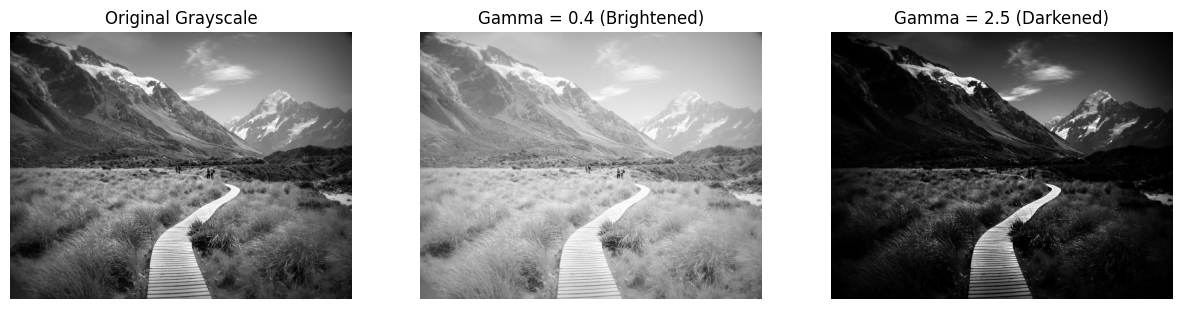

In [42]:
# Apply Gamma Correction
gamma_bright = 0.4
gamma_dark = 2.5

# We can use any of our functions; here we use the vectorized one
img_gamma_bright = gamma_vector(img_gray, gamma_bright)
img_gamma_dark = gamma_vector(img_gray, gamma_dark)

# Display the results side-by-side
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Original Grayscale")
plt.imshow(img_gray, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title(f"Gamma = {gamma_bright} (Brightened)")
plt.imshow(img_gamma_bright, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title(f"Gamma = {gamma_dark} (Darkened)")
plt.imshow(img_gamma_dark, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.show()

### Gamma Correction - Performance Benchmark

This section compares the execution time of our three gamma correction implementations. Because gamma correction involves computationally expensive floating-point conversions and power operations (`**`), the performance gap between explicit Python loops, NumPy vectorization, and the Look-Up Table (LUT) is expected to be massive. We also measure these against the standard OpenCV approach, which utilizes `cv2.LUT`.

In [44]:
gamma_test_val = 1.5
num_runs = 10

# 1. Measure Direct Method
start_time = time.perf_counter()
for _ in range(num_runs):
    gamma_direct(img_gray, gamma_test_val)
time_gamma_direct = ((time.perf_counter() - start_time) / num_runs) * 1000

# 2. Measure Vectorized Method
start_time = time.perf_counter()
for _ in range(num_runs):
    gamma_vector(img_gray, gamma_test_val)
time_gamma_vector = ((time.perf_counter() - start_time) / num_runs) * 1000

# 3. Measure LUT Method
lut = create_gamma_lut(gamma_test_val)  # Pre-create LUT for fair timing
start_time = time.perf_counter()
for _ in range(num_runs):
    gamma_lut(img_gray, lut)
time_gamma_lut = ((time.perf_counter() - start_time) / num_runs) * 1000

# 4. Measure OpenCV Library Method
# OpenCV does not have a single 'cv2.gamma' function. The official standard 
# is to build a LUT and apply it using cv2.LUT, which is heavily optimized in C++.
start_time = time.perf_counter()
for _ in range(num_runs):
    cv2_lut_table = np.array([np.uint8(255.0 * ((i / 255.0) ** gamma_test_val)) for i in range(256)])
    cv2.LUT(img_gray, cv2_lut_table)
time_gamma_cv2 = ((time.perf_counter() - start_time) / num_runs) * 1000

# Print the final Benchmark Table
print("--- Execution Time Comparison (Gamma Correction) ---")
print(f"Direct (Loops):      {time_gamma_direct:.4f} ms")
print(f"Vectorized (NumPy):  {time_gamma_vector:.4f} ms")
print(f"LUT Method:          {time_gamma_lut:.4f} ms")
print(f"OpenCV (cv2.LUT):    {time_gamma_cv2:.4f} ms")

--- Execution Time Comparison (Gamma Correction) ---
Direct (Loops):      2793.0102 ms
Vectorized (NumPy):  17.3903 ms
LUT Method:          3.9319 ms
OpenCV (cv2.LUT):    0.4803 ms


### Benchmark Protocol & Validation

**1. Visual Consistency Across Methods**
As demonstrated in the visual examples above, the final output images are completely identical regardless of the implementation method used (Direct Loops, Vectorized, or LUT). This is expected because all three approaches apply the exact same mathematical logic to the pixels. They do not differ in *what* they calculate, only in *how* the computer executes those calculations under the hood.

**2. Benchmarking Methodology**
To ensure our performance measurements were accurate and reliable, we did not rely on a single execution. Instead, each function was run for multiple iterations (e.g., 10 to 30 runs), and the average execution time was calculated. This methodology mitigates the impact of random background noise or CPU spikes, providing a much more stable and realistic metric.

**3. Isolating the Core Operations**
We designed the benchmark to keep the measured times as "clean" and fair as possible by isolating the core image transformation. Any preliminary setup steps—such as pre-calculating the 256 values for the Look-Up Table (LUT)—were intentionally placed *outside* the measured timer. This ensures that our benchmark strictly compares the raw processing speeds of explicit Python loops against NumPy vectorization and C-optimized library functions (OpenCV), without overhead from one-time preparations.

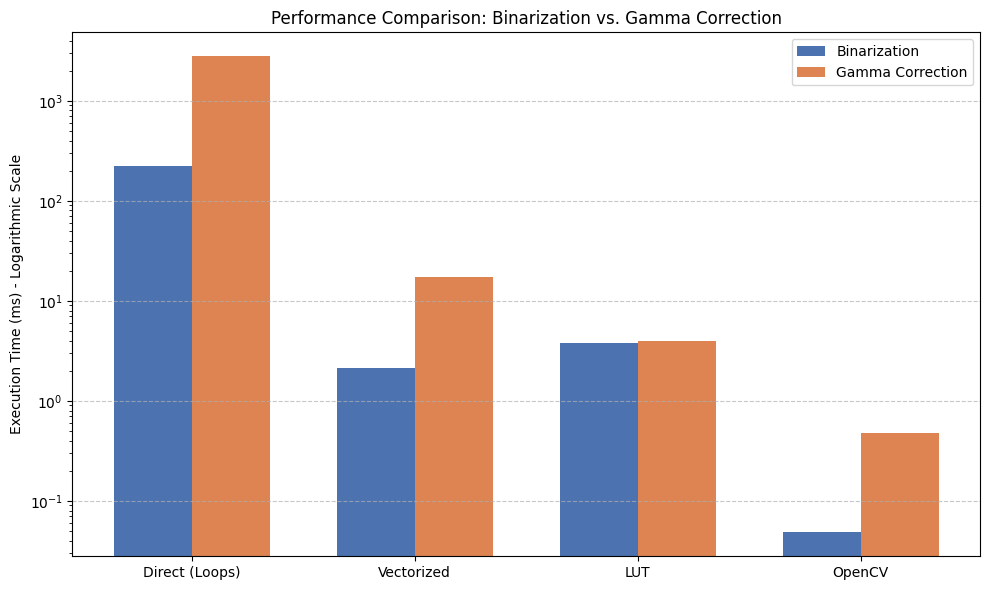

In [45]:
# 1. Prepare the data using the variables already stored in memory
labels = ['Direct (Loops)', 'Vectorized', 'LUT', 'OpenCV']
binary_times = [time_direct, time_vector, time_lut, time_cv2]
gamma_times = [time_gamma_direct, time_gamma_vector, time_gamma_lut, time_gamma_cv2]

x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

# 2. Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot Binarization bars (Blue)
rects1 = ax.bar(x - width/2, binary_times, width, label='Binarization', color='#4C72B0')
# Plot Gamma Correction bars (Orange)
rects2 = ax.bar(x + width/2, gamma_times, width, label='Gamma Correction', color='#DD8452')

# 3. Formatting the graph
ax.set_ylabel('Execution Time (ms) - Logarithmic Scale')
ax.set_title('Performance Comparison: Binarization vs. Gamma Correction')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Set Y-axis to logarithmic scale to handle massive time differences
ax.set_yscale('log')

# Add a grid for easier reading
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Visual Data Analysis: Cross-Algorithm Comparison

The grouped bar chart above provides a comprehensive view of execution times, plotted on a logarithmic scale to accommodate the vast differences in performance. Comparing the Binarization task directly against the Gamma Correction task yields several critical insights:

**1. Mathematical Complexity dictates Loop/Vectorized Time:**
In the "Direct" and "Vectorized" approaches, the Gamma Correction consistently takes significantly longer than Binarization. This is because Binarization relies on a simple boolean comparison (`>` operator), which is extremely cheap for the CPU. Gamma Correction, however, requires converting integers to floating-point numbers, calculating an exponent (`**`), and casting back to integers. This heavy arithmetic burden drastically inflates the execution time.

**2. The Equalizing Power of LUT:**
Notice the "LUT Method" bars. Unlike the previous methods, the execution time for Binarization and Gamma Correction using LUT are almost identical. This perfectly illustrates the power of Look-Up Tables: the heavy floating-point exponent calculations were completed *during the setup phase* (which is not timed here). The actual operation applied to the image is simply an array indexing action (`out = lut[img]`). Array indexing takes the exact same amount of time regardless of whether the table contains binary values or complex gamma calculations.

**3. The OpenCV Standard:**
OpenCV's optimized internal C/C++ architecture remains the fastest across both operations, proving that while NumPy vectorization and indexing are powerful in Python, dedicated compiled libraries with hardware-level optimizations (like SIMD) are essential for real-time image processing applications.